Udacity Pytorch project 2: CIFAR-10 Image Classification

Some of the benchmark results on CIFAR-10 include:

 

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

 

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

 

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

 

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

 

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transform
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from torchinfo import summary
import sys 


In [2]:
#note: bought a refurbed mini mac m4 to get GPUs. cpu was TOO SLOW!!!!! 
#training was taking forever, even for a few epochs!!!!!


In [3]:
#TODO add random_seed to get same outcome 

In [4]:
print('MPS available',torch.backends.mps.is_available())
print('mps built?',torch.backends.mps.is_built())

MPS available True
mps built? True


In [5]:
torch.manual_seed(42) #minor note: for some reason, 42 is a very common number in stack overflow

In [6]:
print('device:',torch.device('mps' if torch.backends.mps.is_available() else 'cpu'))

device: mps


In [31]:
BATCH_SIZE = 4 #keeping very small for DEV... 
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

Load the Dataset

Specific your transforms as a list first. The transforms module is already loaded as transforms
CIFAR-10 is fortunately included in the torchvision module. Then you can create your dataset using the CIFAR10 object from torchvision.datasets. Make sure to specify download=True. 
Once your dataset is created, you'll also need to define a Dataloader from the torch.utils.data module for both train and test set



In [32]:
#Define transforms

# TODO: Define transforms for the training data and testing data
#these transforms are tentative!! Putting something in to get the ball rolling. They may very well suck. 
train_transforms = transform.Compose([  transform.ToTensor()
]) 

test_transforms =  transform.Compose([ transform.ToTensor() ])

#Create training set and define training data loader
#changing batch size from 64 to 32. not sure if I'll need to use a GPU or not. 
trainset = datasets.CIFAR10('data/', download=True, train=True, transform=train_transforms)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

#Create your test set and define test data loader
testset = datasets.CIFAR10('data/', download=True, train=False, transform=test_transforms)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True)

#the 10 classes in the dataset
classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')


Explore the Dataset

Using matplotlib, numpy and torch, explore the dimensions of your data 

you can view images using the show5 function below - it takes a dataloader as an argument. Remember that normalized images will look really weird to you. You may want to try changing your transforms to view images.Typically using no transforms other than toTensor() works well for viewing - but not as well for training your network. If show5 doesn't work, go back and check your code for creating your dataloaders and your training/test sets.


In [33]:

print(len(trainset))
print(len(testset))


50000
10000


In [10]:
def show5(img_loader):
    dataiter=iter(img_loader)

    batch=next(dataiter)
    labels=batch[1][0:5]
    image=batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
        image=images[i].numpy()
        plt.imshow(image.T)
        plt.show()
    

ship


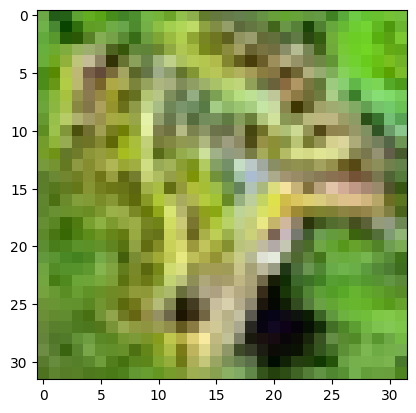

horse


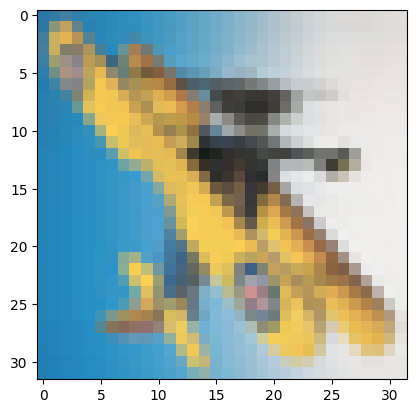

car


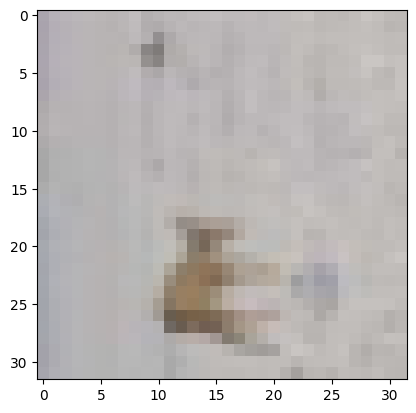

frog


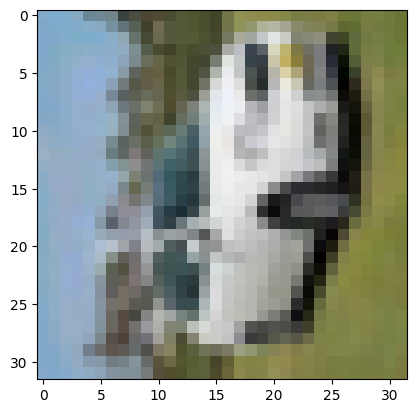

In [11]:





# Run this to test your data loader
images, labels = next(iter(trainloader))
#helper.imshow(images[0], normalize=False)    

dataiter=iter(trainloader)
batch=next(dataiter)
labels=batch[1][0:4]
image=batch[0][0:4]
for i in range(4):
    print(classes[labels[i]])
    image=images[i].numpy()
    plt.imshow(image.T)
    plt.show()


In [12]:
# #explore data
# image, label = next(iter(trainloader))
# #image.shape
# print(image[0][0].shape)
# show5(trainloader)
#do more exploring... need to get proper shape before building the network. 
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(type(images))
print(images.shape)
print(labels.shape)
print(len(images))
print(len(dataiter))

<class 'torch.Tensor'>
torch.Size([4, 3, 32, 32])
torch.Size([4])
4
12500


In [23]:
#this shape looks ok 
next(iter(trainloader))[0].shape

torch.Size([4, 3, 32, 32])

In [24]:
print(3*32*32)

3072


Build your Neural Network

Using the layers in torch.nn (which has been imported as nn) and the torch.nn.Functional module (imported as F)
construct a neural network based on the parameters of the dataset. Feel free to consult a model of any architecture-feedforward, convolutional or even something more advanced.

In [15]:
#REFERENCE https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
#torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)

In [16]:
# #code here to build the network 
#NOTE: this was used for debugging... shape mismatch... 
# #placeholder model. no commitment to keep this. again, this won't work as the shape does not fit the cifar10 data
# #added dropout. 20% to start 
class Classifier_shapeprint(nn.Module):
    def __init__(self,input_shape):
        super().__init__()
        self.dropout = nn.Dropout(0.2)
        self.fc0 = nn.Conv2d(in_channels=input_shape,out_channels=256,kernel_size=3)
        #adding a second conv2d.
        self.fc1 = nn.Conv2d(in_channels=256,out_channels=128,kernel_size=3)
        #self.fc2 = nn.Linear(50400, 64)
        self.fc2 = nn.Linear(4608, 64) #NOTE: second conv2d changes shape from 50400 to 4608
       
        self.fc3 = nn.Linear(64, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 10)
        #TODO incorporate this. 
        self.dropoutprobability = 0
        #self.dropout = nn.Dropout(self.dropoutprobability) 
        
    def forward(self, x):
        x = self.dropout(x)
        #x = self.fc0(x)
        x = F.relu(self.fc0(x))
        print(x.shape)
    
        x = F.max_pool2d(x,2)
        print(x.shape)
        x = F.relu(self.fc1(x))
        print(x.shape)
        # make sure input tensor is flattened
        x = F.max_pool2d(x,2)
        print(x.shape)
        x = x.view(x.shape[0], -1)
        print(x.shape)
        
        x = F.relu(self.fc2(x))
        print(x.shape)
        x = F.relu(self.fc3(x))
        print(x.shape)
        x = F.relu(self.fc4(x))
        print(x.shape)
        x = F.relu(self.fc5(x))
        print(x.shape)
        x = F.log_softmax(x, dim=1)
        print(x.shape)
        return x

In [284]:
#code for loss fx and optimizer here
model = Classifier_shapeprint(input_shape=3).to(DEVICE)
#model.dropoutprobability = 0.2
#placeholder loss function and optimizer
criterion = nn.NLLLoss(reduction='sum')
#criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)
#optimizer = optim.SGD(model.parameters(), lr=0.01)


In [285]:
# #train network 


epochs = 1

for e in range(epochs):
    print('churning thru epoch number:',e)
    running_loss = 0
    model.train()
    for images, labels in trainloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        sys.exit()
    else:
        print(f"Training loss: {running_loss/len(trainloader)}")
        sys.exit()
print('fini')

churning thru epoch number: 0
torch.Size([4, 256, 30, 30])
torch.Size([4, 256, 15, 15])
torch.Size([4, 128, 13, 13])
torch.Size([4, 128, 6, 6])
torch.Size([4, 4608])
torch.Size([4, 64])
torch.Size([4, 128])
torch.Size([4, 64])
torch.Size([4, 10])
torch.Size([4, 10])


SystemExit: 

In [53]:
#code here to build the network 
#added dropout. 20% to start 
class Classifier(nn.Module):
    def __init__(self,input_shape):
        super().__init__()
        self.dropout = nn.Dropout(0.2) #is 20% ideal?
        #is 256 for the out channels too high? 
        self.conv1 = nn.Conv2d(in_channels=input_shape,out_channels=128,kernel_size=3,padding=1)
        #adding a second conv2d.
        self.conv2 = nn.Conv2d(in_channels=128,out_channels=64,kernel_size=3,padding=1)
        
        #self.fc1= nn.Linear(57600, 64)
        #self.fc1 = nn.Linear(4608, 64) #NOTE: second conv2d changes shape from 50400 to 4608
       
        self.conv3 = nn.Conv2d(in_channels=64,out_channels=32,kernel_size=3,padding=1)
        self.fc1 = nn.Linear(800, 32)
        self.fc2 = nn.Linear(32, 10)
        #TODO incorporate this. 

        
    def forward(self, x):
        x = self.dropout(x)
  
        x = F.relu(self.conv1(x))
        #print(x.shape)
        x = F.max_pool2d(x,kernel_size=2,stride=2,padding=1)
        x = F.relu(self.conv2(x))
        #print(x.shape)
        x = F.max_pool2d(x,kernel_size=2,stride=2,padding=1)        
        x = F.relu(self.conv3(x))
        #print(x.shape)
        x = F.max_pool2d(x,kernel_size=2,stride=2,padding=1)
        
        #print(x.shape)
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)
        #print(x.shape)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        #x = F.relu(self.fc4(x))
        #x = F.relu(self.fc3(x))
        #x = F.relu(self.fc4(x))
        
        #x = F.log_softmax(x, dim=1)
        
        return x

In [54]:

#c.dropoutprobability=0.2
#take 1 image
image, label = next(iter(dataiter))
print(type(image))
print(image.shape)
print(label.shape)
print(len(image))
one_image, one_label = image[0].unsqueeze(dim=0), label[0]
print(type(one_image))
print(one_image.shape)
#print('multiplied:',one_image.mul())
print(label.shape)
print(len(one_image))
# c.eval() # put in test mode
# with torch.inference_mode():
#     pred = c(one_image.to(DEVICE))
#     pred =torch.softmax(pred, dim=1) #convert to probabilities 
#     print(pred)
#     print(pred.sum()) #sanity check

<class 'torch.Tensor'>
torch.Size([4, 3, 32, 32])
torch.Size([4])
4
<class 'torch.Tensor'>
torch.Size([1, 3, 32, 32])
torch.Size([4])
1


Specify a loss function and an optimizer and instantiate the model.
if you use a less common loss function, please note why you chose that function in a comment. 

In [57]:
#code for loss fx and optimizer here
model = Classifier(input_shape=3)
model=model.to(DEVICE)
#model.dropoutprobability = 0.2
#placeholder loss function and optimizer
#criterion = torch.nn.BCEWithLogitsLoss(pos_weight=(4,32))) 
#nn.NLLLoss(reduction='sum')
#criterion = nn.MSELoss()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)
#optimizer = optim.SGD(model.parameters(), lr=0.01)


Running your Neural Network 

use whatever method you like to train your neural network and ensure you record the average loss at each epoch. Don't forget to use torch.device() and the .to() method for both your model and data if you are using GPU

if you want to print your loss during each epoch, you can use the enumerate function and print the loss after a set of batches. 250 batches works well for most people. 

In [58]:
#train network through 1 epoch (fast QC) 
epochs = 1

for e in range(epochs):
    print('churning thru epoch number:',e)
    running_loss = 0
    model.train()
    for images, labels in trainloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        log_ps = model(images)
        loss = criterion(log_ps, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        #sys.exit()
    else:
        print(f"Training loss: {running_loss/len(trainloader)}")
        #sys.exit()
print('fini')

churning thru epoch number: 0
Training loss: 1.771576047258377
fini


In [59]:
#code to run the network 

#placeholder training/testing 

# #pull from the right loader
# image, label = next(iter(trainloader))


#one epoch to start just to work out the kinks, if any
epochs = 2

train_losses, test_losses, test_accuracies = [], [], []
for e in range(epochs):
    print('churning thru epoch:',e)
    tot_train_loss = 0
    model.train()
    for images, labels in trainloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        log_ps = model(images)
        loss = criterion(log_ps, labels)
        tot_train_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    else:
        tot_test_loss = 0
        test_correct = 0  # Number of correct predictions on the test set
        
        # # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            model.eval()
            for images, labels in testloader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                log_ps = model(images)
                loss = criterion(log_ps, labels)
                tot_test_loss += loss.item()

                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                test_correct += equals.sum().item()

        # Get mean loss to enable comparison between train and test sets
        train_loss = tot_train_loss / len(trainloader.dataset)
        test_loss = tot_test_loss / len(testloader.dataset)

        # At completion of epoch
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_correct / len(testloader.dataset))
        print("Epoch: {}/{}.. ".format(e+1, epochs),
              "Training Loss: {:.3f}.. ".format(train_loss),
              "Test Loss: {:.3f}.. ".format(test_loss),
              "Test Accuracy: {:.3f}".format(test_correct / len(testloader.dataset)))
    
print('done')

churning thru epoch: 0
Epoch: 1/2..  Training Loss: 0.401..  Test Loss: 0.487..  Test Accuracy: 0.325
churning thru epoch: 1
Epoch: 2/2..  Training Loss: 0.392..  Test Loss: 0.650..  Test Accuracy: 0.255
done


Plot the training loss (and validation loss/accuracy, if recorded)

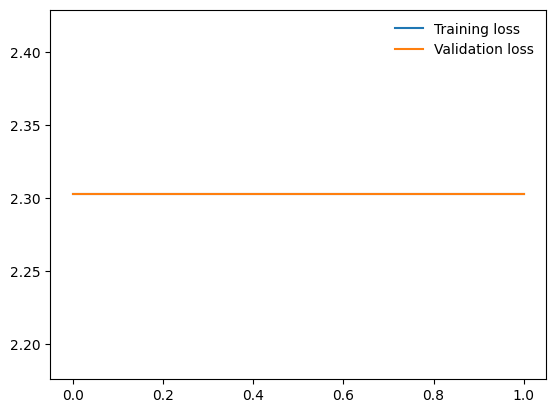

In [299]:
#showing the plots 
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

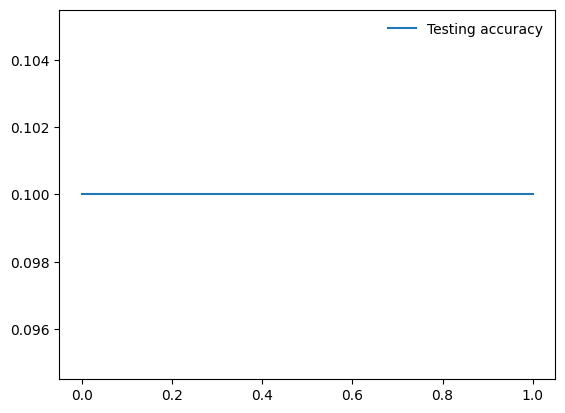

In [258]:

plt.plot(test_accuracies, label='Testing accuracy')
plt.legend(frameon=False)

Testing your model 

using the previously created DataLoader for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is under 45% you'll need to make improvements. Go back and check your model architecture, loss function, and optimizer to make sure they are appropriate for an image classification task. 

Saving your model 

using torch.save, save your model for future loading

In [239]:
#code to save the model 
torch.save(model.state_dict(), "CIFAR_model_baseline2.pth")

Make a recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below. 

In [ ]:
#put your explanation here. 